In [1]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
import re
import random
import math
from scipy.stats import chi2_contingency

In [2]:
tree = 'files/summary_baltic.nwk'
traits_file = 'files/traits.json'

flyways = ['mississippi_flyway', 'atlantic_flyway', 'central_flyway', 'pacific_flyway']

with open(traits_file) as f:
    traits = json.load(f)

mytree= bt.loadNewick(tree, absoluteTime= False)
node_traits = traits["nodes"]

flyway_total_count = {flyway:0 for flyway in flyways}

for k in mytree.Objects:
    
    name = k.traits["label"] if k.is_node() else k.name
    
    k.traits["subtype"] = node_traits[name]["subtype"]
    k.traits["flyway"] = node_traits[name]["flyway"]
    k.traits["broad"] = node_traits[name]["broad"]
    k.traits["order"] = node_traits[name]["order"]
    
    if k.is_leaf() and k.traits["flyway"] != "unknown":
        
        flyway_total_count[k.traits['flyway']] += 1
        
        

In [3]:
flyway_total_count

{'mississippi_flyway': 369,
 'atlantic_flyway': 255,
 'central_flyway': 339,
 'pacific_flyway': 221}

In [4]:
total = sum(flyway_total_count.values())

props = {k: v / total for k, v in flyway_total_count.items()}

props

{'mississippi_flyway': 0.31165540540540543,
 'atlantic_flyway': 0.21537162162162163,
 'central_flyway': 0.28631756756756754,
 'pacific_flyway': 0.1866554054054054}

In [5]:
flyway_count = {flyway:0 for flyway in flyways}

for k in mytree.Objects:
    
    if k.is_node() and k.traits["is_reassorted"] and k.traits['flyway'] != 'unknown':
        
        flyway_count[k.traits['flyway']] += 1
        

In [6]:
flyway_count

{'mississippi_flyway': 118,
 'atlantic_flyway': 48,
 'central_flyway': 91,
 'pacific_flyway': 48}

In [7]:
total_real = sum(flyway_count.values())

props_real = {k: v / total_real for k, v in flyway_count.items()}

props_real

{'mississippi_flyway': 0.38688524590163936,
 'atlantic_flyway': 0.15737704918032788,
 'central_flyway': 0.2983606557377049,
 'pacific_flyway': 0.15737704918032788}

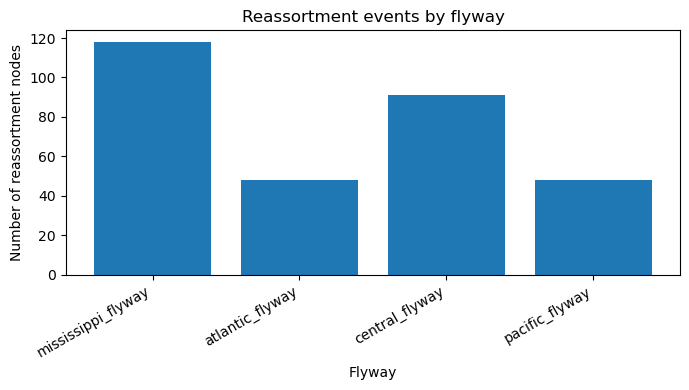

In [8]:
import matplotlib.pyplot as plt

flyways = list(flyway_count.keys())
counts = list(flyway_count.values())

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(flyways, counts)
ax.set_ylabel("Number of reassortment nodes")
ax.set_xlabel("Flyway")
ax.set_title("Reassortment events by flyway")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


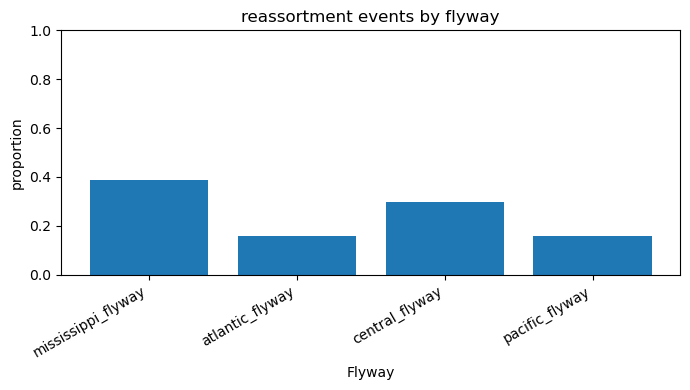

In [9]:
import matplotlib.pyplot as plt

flyways = list(props_real.keys())
counts = list(props_real.values())

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(flyways, counts)
ax.set_ylabel("proportion")
ax.set_xlabel("Flyway")
ax.set_title("reassortment events by flyway")
ax.set_ylim(0,1)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [10]:
df = pd.DataFrame({
    "flyway": flyways,
    "total_leaves": [flyway_total_count[f] for f in flyways],
    "reassort_nodes": [flyway_count[f] for f in flyways],
})

df["total_frac"] = df["total_leaves"] / df["total_leaves"].sum()
df["reassort_frac"] = df["reassort_nodes"] / df["reassort_nodes"].sum()

df


,flyway,total_leaves,reassort_nodes,total_frac,reassort_frac
0,mississippi_flyway,369,118,0.311655,0.386885
1,atlantic_flyway,255,48,0.215372,0.157377
2,central_flyway,339,91,0.286318,0.298361
3,pacific_flyway,221,48,0.186655,0.157377


In [28]:
from scipy.stats import binomtest

results = {}

total_reassort = sum(flyway_count.values())
total_leaves = sum(flyway_total_count.values())
num_tests = len(flyways)

for flyway in flyways:
    
    expected = flyway_total_count[flyway] / total_leaves # probability a node would be a certain flyway
    observed = flyway_count[flyway] / total_reassort
    
    res = binomtest(
        flyway_count[flyway],
        n=total_reassort,
        p=expected,
        alternative="two-sided"
    )
    
    results[flyway] = {
        "expected": expected,
        "observed": observed,
        "direction": "over" if expected < observed else "under",
        "p_value": 1.0 if res.pvalue * num_tests > 1 else res.pvalue * num_tests, # bonferroni correction
        "reject": "true" if res.pvalue * num_tests < 0.05 else "false"
    }

results


{'mississippi_flyway': {'expected': 0.31165540540540543,
  'observed': 0.38688524590163936,
  'direction': 'over',
  'p_value': 0.021396337573516375,
  'reject': 'true'},
 'atlantic_flyway': {'expected': 0.21537162162162163,
  'observed': 0.15737704918032788,
  'direction': 'under',
  'p_value': 0.04862914813114698,
  'reject': 'true'},
 'central_flyway': {'expected': 0.28631756756756754,
  'observed': 0.2983606557377049,
  'direction': 'over',
  'p_value': 1.0,
  'reject': 'false'},
 'pacific_flyway': {'expected': 0.1866554054054054,
  'observed': 0.15737704918032788,
  'direction': 'under',
  'p_value': 0.8455093744698856,
  'reject': 'false'}}

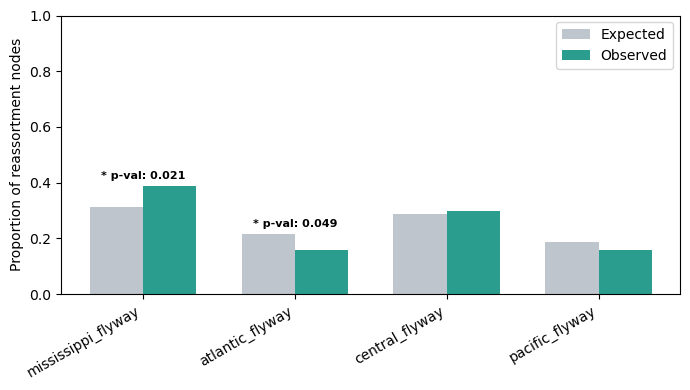

In [53]:
flyways = list(results.keys())
observed = [results[f]["observed"] for f in flyways]
expected = [results[f]["expected"] for f in flyways]
pvals = [results[f]["p_value"] for f in flyways]
sig = [results[f]["reject"] == "true" for f in flyways]

x = np.arange(len(flyways))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x - width/2, expected, width, label="Expected", color="#BFC5CC")   # soft gray
ax.bar(x + width/2, observed, width, label="Observed", color="#2A9D8F")   # teal

for i, is_sig in enumerate(sig):
    if is_sig:
        ax.text(i, max(observed[i], expected[i]) + 0.02, f"* p-val: {pvals[i]:.3f}", 
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(flyways, rotation=30, ha="right")
ax.set_ylabel("Proportion of reassortment nodes")
ax.set_ylim(0,1)
ax.legend()

plt.tight_layout()
plt.show()


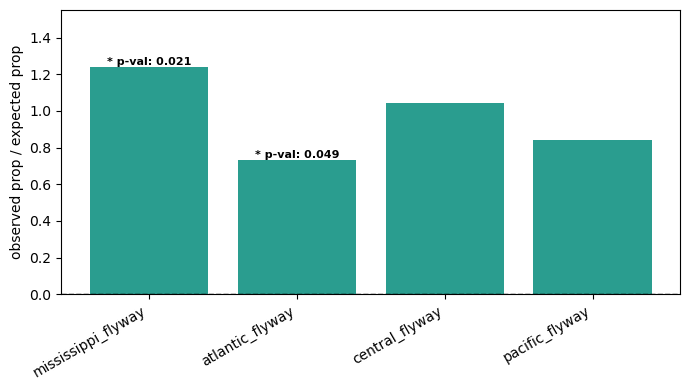

In [63]:
div = [results[f]["observed"] / results[f]["expected"] for f in flyways]

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, linestyle="--", linewidth=1, color = "black")

ax.bar(flyways, delta, color = '#2A9D8F')

for i, is_sig in enumerate(sig):
    if is_sig:
        ax.text(i, div[i] + 0.01, f"* p-val: {pvals[i]:.3f}",
                ha="center",
                fontsize=8, fontweight="bold")

ax.set_ylabel("observed prop / expected prop")
ax.set_ylim(0,1.55)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


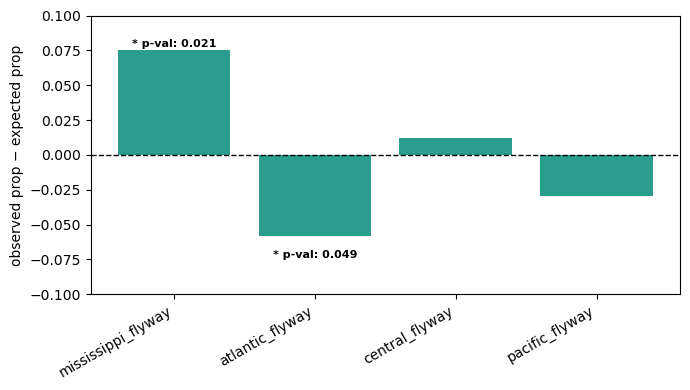

In [52]:
delta = [results[f]["observed"] - results[f]["expected"] for f in flyways]

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, linestyle="--", linewidth=1, color = "black")

ax.bar(flyways, delta, color = '#2A9D8F')

for i, is_sig in enumerate(sig):
    if is_sig:
        ax.text(i, delta[i] + (0.001 if delta[i] > 0 else -0.01), f"* p-val: {pvals[i]:.3f}",
                ha="center", va="bottom" if delta[i] > 0 else "top",
                fontsize=8, fontweight="bold")

ax.set_ylabel("observed prop − expected prop")
ax.set_ylim(-0.10,0.1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
